Excellent. If you are locked in, I am locked in. Let's move immediately to **Day 9: The Sigmoid Function**.

---

### Lecture 1: The "Squishing Machine" (Intuition)

Yesterday, you calculated raw $z$-scores for 5 emails: `[-13, -6, 8, 15, -7]`.

Using a "Hard Threshold," the computer drew a rigid line: anything $\ge 0$ is Spam (1), anything $< 0$ is Not Spam (0).

But in the real world, you don't just want an answer; you want **confidence**.

* Email C scored an `8`.
* Email D scored a `15`.
Both are Spam, but Email D is *way* more spammy. If a user asks the AI, "How confident are you that Email D is spam?", the AI can't say, "I am 15 confident." That means nothing.

We need a mathematical hydraulic press. We need a function that can take *any* number in the universe—from negative infinity to positive infinity—and squish it down so it always fits perfectly between **0 and 1** (representing 0% to 100% probability).

### Lecture 2: The Math of the S-Curve

The mathematical function that does this squishing is called the **Sigmoid Function**. (Also known as the Logistic Function, which is why this algorithm is called *Logistic Regression*).

Write this formula down in your notebook. You will see it for the rest of your Machine Learning career:

$$g(z) = \frac{1}{1 + e^{-z}}$$

Let's break this down using the Feynman Technique:

* **$z$**: This is your raw score from yesterday (e.g., $15$, or $-7$).
* **$e$**: This is Euler's Number (approx. $2.718$). Don't overthink it; in programming, it's just a constant number built into nature, like $\pi$ (Pi).
* **$e^{-z}$**: This is where the magic happens. We raise $e$ to the power of *negative* $z$.

**Let's test the extremes in our heads to see how the squishing works:**

1. **The Massive Spam (z = 100):** If $z$ is 100, $e^{-100}$ is a microscopic number (basically $0$). The formula becomes $\frac{1}{1 + 0}$, which equals **$1.0$ (100% Probability of Spam)**.
2. **The Safe Email (z = -100):** If $z$ is -100, $e^{-(-100)}$ becomes $e^{100}$, which is a massively huge number. The formula becomes $\frac{1}{1 + \text{Massive Number}}$. If you divide 1 pizza among a billion people, everyone gets basically **$0$ (0% Probability of Spam)**.
3. **The Dead-Center Fence (z = 0):** If $z$ is exactly 0, $e^{-0}$ equals exactly 1. The formula becomes $\frac{1}{1 + 1} = \frac{1}{2}$, which is **$0.5$ (Exactly 50% Probability)**.

Notice how beautifully that links to yesterday? A score of exactly `0` gives us exactly a 50/50 probability.

### Lecture 3: Moving into Python

In Python, we don't calculate $e$ by hand. NumPy has a built-in function called `np.exp(x)` which calculates $e^x$ instantly.

I have generated a new file for you. We are going to build your `sigmoid` function, and then use Matplotlib to literally draw the famous "S-Curve" shape of this function so you can see the hydraulic press in action.

---

### 📝 Your Day 9 Assignment

1. Fill out the mathematical logic in the `sigmoid(z)` function in the file above.
2. Run the script in your VS Code.

**Your Submission:** Reply by pasting your completed `sigmoid(z)` function.
Also, tell me: **Based on the printout, exactly what percentage (%) probability of being spam did Email C (the one that scored $z=8$) get?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Build the squishing machine 
def sigmoid(z):
    # YOUR CODE HERE:
    # Translate the math formula g(z) = 1 / (1 + e^-z) into NumPy code.
    # Hint: Use np.exp() for e. 
    g_z = 1 / (1 + np.exp(-z))
    return g_z 

# Test it on z-scores from yesterday! 
# # [Email A, Email B, Email C, Email D, Email E]
z_scores = np.array([-13, -6, 8, 15, -7])

probabilities = sigmoid(z_scores)

print("--- Email Probabilities ---")
for i, prob in enumerate(probabilities):
    print(f"Email {chr(65+i)} Probability of Sapm: {prob*100:.2f}%")

--- Email Probabilities ---
Email A Probability of Sapm: 0.00%
Email B Probability of Sapm: 0.25%
Email C Probability of Sapm: 99.97%
Email D Probability of Sapm: 100.00%
Email E Probability of Sapm: 0.09%


In [3]:
# 3 Visualize the S-curve (Run this to see magic!)
# Generate 100 points between -10 to 10 

z_plot = np.linspace(-10, 10, 100)
g_plot = sigmoid(z_plot)

print(f"Z-plot: {z_plot}")
print(f"G_plot: {g_plot}")

Z-plot: [-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   

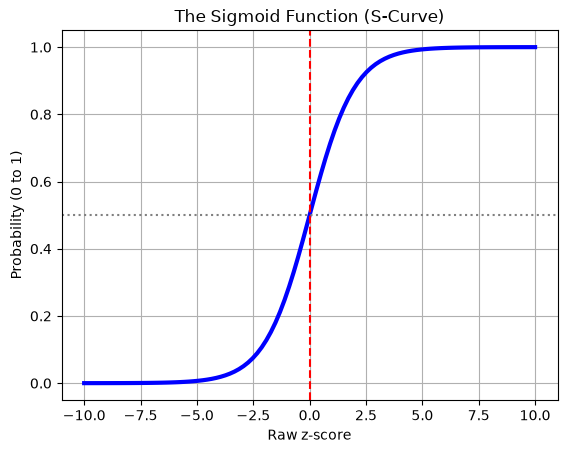

In [4]:
plt.plot(z_plot, g_plot, color='blue', linewidth=3)
# Draw the boundary line at z = 0 
plt.axvline(0, color='red', linestyle='--')
# Draw the 50 % line
plt.axhline(0.5, color='gray', linestyle=':')
plt.title('The Sigmoid Function (S-Curve)')
plt.xlabel('Raw z-score')
plt.ylabel('Probability (0 to 1)')
plt.grid(True)
plt.show()